<a href="https://colab.research.google.com/github/narendra8839/Deep-Learning-Lab/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay



In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", iris.target_names)


Dataset loaded successfully!
Number of samples: 150
Number of features: 4
Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 120
Testing samples: 30


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [6]:
def create_model(learning_rate):

    model = tf.keras.Sequential([

        tf.keras.layers.Dense(
            10,
            activation='relu',
            input_shape=(4,)
        ),

        tf.keras.layers.Dense(
            10,
            activation='relu'
        ),


        tf.keras.layers.Dense(
            3,
            activation='softmax'
        )
    ])


    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [7]:
learning_rates = [0.001, 0.01, 0.1]
epochs = 100

results_lr = []

print("\n==============================================")
print("   EFFECT OF DIFFERENT LEARNING RATES")
print("==============================================")

for lr in learning_rates:

    print("\nTraining with Learning Rate:", lr)


    model = create_model(lr)


    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=16,
        verbose=0
    )


    predictions = model.predict(X_test, verbose=0)

    y_pred = np.argmax(predictions, axis=1)


    accuracy = accuracy_score(y_test, y_pred)

    results_lr.append({
        "Learning Rate": lr,
        "Epochs": epochs,
        "Test Accuracy": accuracy
    })

    print("Test Accuracy:", accuracy * 100, "%")



   EFFECT OF DIFFERENT LEARNING RATES

Training with Learning Rate: 0.001


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 96.66666666666667 %

Training with Learning Rate: 0.01


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 96.66666666666667 %

Training with Learning Rate: 0.1


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 93.33333333333333 %


In [8]:
results_lr_df = pd.DataFrame(results_lr)

print("\nLearning Rate Results:")
print(results_lr_df)


Learning Rate Results:
   Learning Rate  Epochs  Test Accuracy
0          0.001     100       0.966667
1          0.010     100       0.966667
2          0.100     100       0.933333


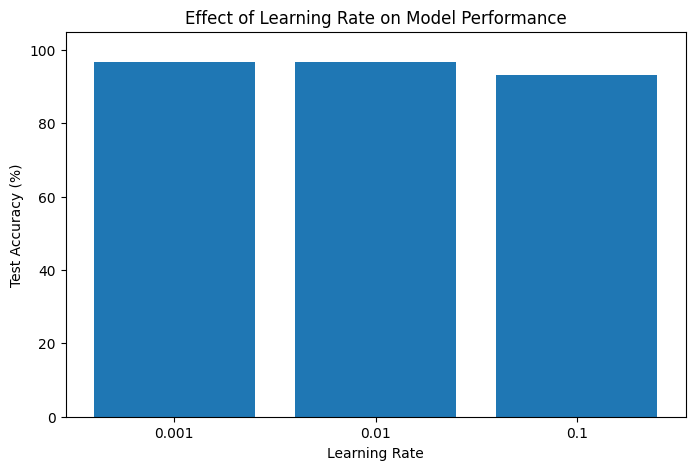

In [9]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_lr_df["Learning Rate"].astype(str),
    results_lr_df["Test Accuracy"] * 100
)

plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy (%)")
plt.title("Effect of Learning Rate on Model Performance")

plt.ylim(0, 105)
plt.show()


In [10]:
epoch_values = [10, 25, 50, 100, 200]

learning_rate = 0.001

results_epochs = []

print("\n==============================================")
print("       EFFECT OF DIFFERENT EPOCHS")
print("==============================================")

for epoch in epoch_values:

    print("\nTraining with Epochs:", epoch)


    model = create_model(learning_rate)


    history = model.fit(
        X_train,
        y_train,
        epochs=epoch,
        batch_size=16,
        verbose=0
    )


    predictions = model.predict(X_test, verbose=0)

    y_pred = np.argmax(predictions, axis=1)


    accuracy = accuracy_score(y_test, y_pred)

    results_epochs.append({
        "Epochs": epoch,
        "Learning Rate": learning_rate,
        "Test Accuracy": accuracy
    })

    print("Test Accuracy:", accuracy * 100, "%")



       EFFECT OF DIFFERENT EPOCHS

Training with Epochs: 10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 63.33333333333333 %

Training with Epochs: 25


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 83.33333333333334 %

Training with Epochs: 50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 90.0 %

Training with Epochs: 100
Test Accuracy: 93.33333333333333 %

Training with Epochs: 200


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 93.33333333333333 %


In [11]:
results_epochs_df = pd.DataFrame(results_epochs)

print("\nEpoch Results:")
print(results_epochs_df)




Epoch Results:
   Epochs  Learning Rate  Test Accuracy
0      10          0.001       0.633333
1      25          0.001       0.833333
2      50          0.001       0.900000
3     100          0.001       0.933333
4     200          0.001       0.933333


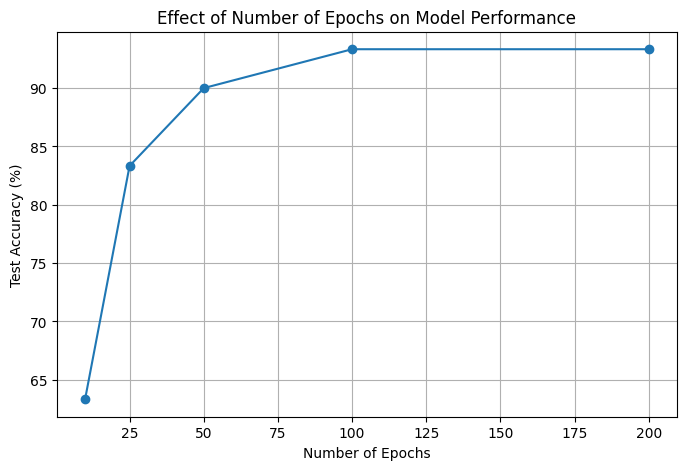

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_epochs_df["Epochs"],
    results_epochs_df["Test Accuracy"] * 100,
    marker='o'
)

plt.xlabel("Number of Epochs")
plt.ylabel("Test Accuracy (%)")
plt.title("Effect of Number of Epochs on Model Performance")

plt.grid(True)
plt.show()



In [13]:
final_learning_rate = 0.001
final_epochs = 100

final_model = create_model(final_learning_rate)

print("\n==============================================")
print("             TRAINING FINAL MODEL")
print("==============================================")

final_history = final_model.fit(
    X_train,
    y_train,
    epochs=final_epochs,
    batch_size=16,
    verbose=0
)

print("Final model training completed.")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



             TRAINING FINAL MODEL
Final model training completed.


In [14]:
test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nFinal Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy * 100, "%")



Final Test Loss: 0.11160682886838913
Final Test Accuracy: 96.66666388511658 %


In [15]:
predictions = final_model.predict(X_test, verbose=0)

y_pred = np.argmax(predictions, axis=1)


In [16]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)




Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


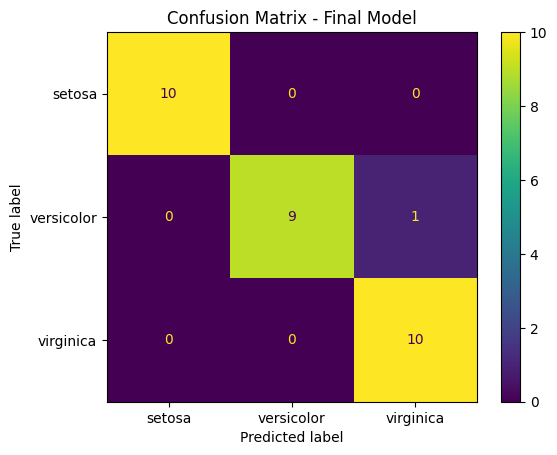

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Confusion Matrix - Final Model")
plt.show()


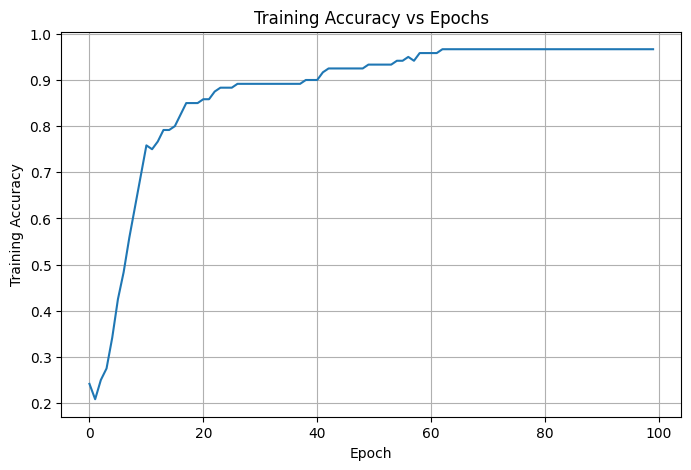

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history['accuracy']
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epochs")

plt.grid(True)
plt.show()

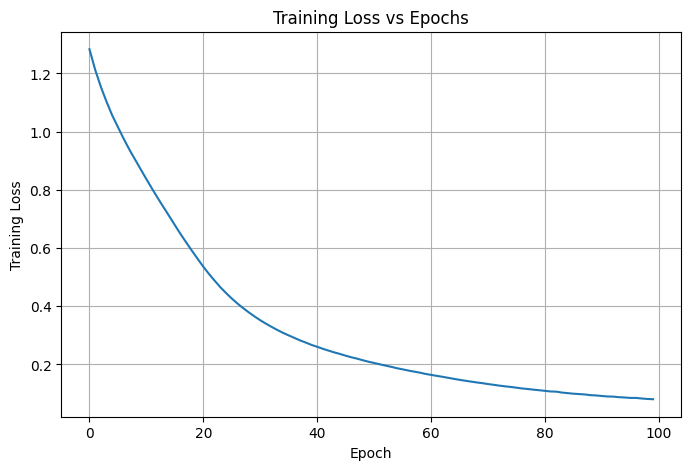

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history['loss']
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")

plt.grid(True)
plt.show()

In [20]:
print("\n==============================================")
print("                 FINAL SUMMARY")
print("==============================================")

print("Final Learning Rate:", final_learning_rate)
print("Final Number of Epochs:", final_epochs)
print("Final Test Accuracy:", test_accuracy * 100, "%")

print("\nThe neural network uses:")
print("- Input layer: 4 neurons")
print("- Hidden layer 1: 10 neurons")
print("- Hidden layer 2: 10 neurons")
print("- Output layer: 3 neurons")
print("- Activation: ReLU for hidden layers")
print("- Activation: Softmax for output layer")
print("- Optimizer: Adam")


                 FINAL SUMMARY
Final Learning Rate: 0.001
Final Number of Epochs: 100
Final Test Accuracy: 96.66666388511658 %

The neural network uses:
- Input layer: 4 neurons
- Hidden layer 1: 10 neurons
- Hidden layer 2: 10 neurons
- Output layer: 3 neurons
- Activation: ReLU for hidden layers
- Activation: Softmax for output layer
- Optimizer: Adam
